In [2]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis

In [3]:
def compute_radial_spectrum_de(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

In [4]:
def compute_radial_spectrum_em(fld,dx,dy,dtype=float,mask=None):
    """
    Compute the radial spectra of a 2D field
    input:
    fld : np.array or any 2D field
    dx : (float)
         grid x resolution
    dy : (float)
         grid y resolution
    """
    (nx,ny) = np.shape(np.asarray(fld))
    x = np.arange(dtype(nx)) * dx
    y = np.arange(dtype(ny)) * dy
    kx = np.fft.fftfreq(nx,d=dx) *2*np.pi 
    ky = np.fft.fftfreq(ny,d=dy) *2*np.pi 
    
    #isotropizing
    aa = np.sqrt(np.repeat(kx[np.newaxis,:]**2,ny,axis=0).transpose() + \
                 np.repeat(ky[np.newaxis,:]**2,nx,axis=0))   
    
    #resolution in k_r
    dk = kx[2] - kx[1]
    nk = np.int64(np.max(aa)/dk  + 1)
    kk = np.arange(dtype(nk)) * dk
    i1 = (aa/dk).astype(np.int64)
    i2 = i1 + 1
    s2 = aa/dk - i1.astype(dtype)
    s1 = 1 - s2
    tags=['kk','sp']
    
 
    sps= np.recarray((nk,),dtype=[(i,dtype) for i in tags])
    sps.kk=kk
    sp = np.zeros(nk,dtype=dtype)
    ff=np.abs(np.fft.ifft2(fld))**2
    #if mask is not None:  
    #    if (np.shape(mask) == ff.shape): 
    #    ff * = np.asarray(mask)
    f1 = ff*s1
    f2 = ff*s2

    for i in range(nx):
        for j in range(ny):
            if i2[i,j] < nk :
                sp[i2[i,j]] += f2[i,j] 
                sp[i1[i,j]] += f1[i,j] 
    sps['sp']=sp/dk
    
    
    return sps

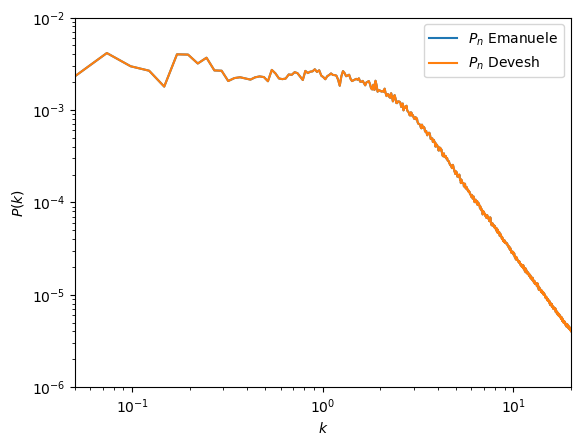

In [5]:
#Density 

# Read the HDF5 file
File_Dn = '/DATA/DEVESH/ApJ2015/Dn1_ApJ_t200.h5'

with h5py.File(File_Dn, 'r') as fDn:
    data_Dn = fDn['DS1'][:]

dx = 0.125
dy = 0.125
spectrum_D_em = compute_radial_spectrum_em(data_Dn, dx, dy)
spectrum_D_de = compute_radial_spectrum_de(data_Dn, dx, dy)

# Plot
plt.loglog(spectrum_D_em.kk, spectrum_D_em.sp, label=r'$P_{n}$ Emanuele')
plt.loglog(spectrum_D_de.kk, spectrum_D_de.sp, label=r'$P_{n}$ Devesh')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xlim(5e-2, 20)
plt.ylim(1e-6, 1e-2)
plt.legend()
plt.show()

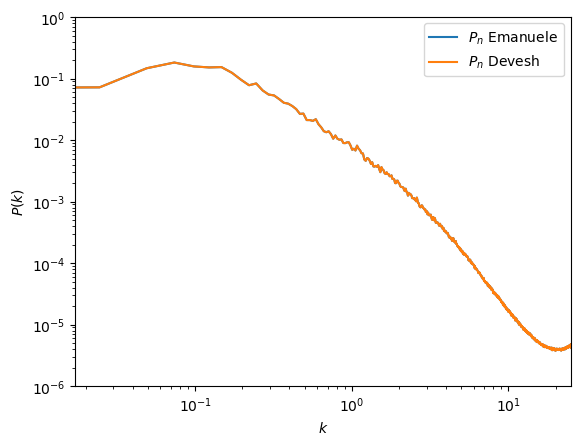

In [7]:
#Magnetic Field

# Read the HDF5 file
File_Bx = '/DATA/DEVESH/ApJ2015/Bx_ApJ_t200.h5'
File_By = '/DATA/DEVESH/ApJ2015/By_ApJ_t200.h5'

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
    data_Bx = fBx['DS1'][:]
    data_By = fBy['DS1'][:]

dx = 0.125
dy = 0.125
spectrum_Bx_em = compute_radial_spectrum_em(data_Bx, dx, dy)
spectrum_By_em = compute_radial_spectrum_em(data_By, dx, dy)
spectrum_Bp_em = np.recarray(spectrum_Bx_em.shape, dtype=spectrum_Bx_em.dtype)
spectrum_Bp_em.kk = spectrum_Bx_em.kk
spectrum_Bp_em.sp = spectrum_Bx_em.sp + spectrum_By_em.sp

spectrum_Bx_de = compute_radial_spectrum_de(data_Bx, dx, dy)
spectrum_By_de = compute_radial_spectrum_de(data_By, dx, dy)
spectrum_Bp_de = np.recarray(spectrum_Bx_de.shape, dtype=spectrum_Bx_de.dtype)
spectrum_Bp_de.kk = spectrum_Bx_de.kk
spectrum_Bp_de.sp = spectrum_Bx_de.sp + spectrum_By_de.sp

# Plot
plt.loglog(spectrum_Bp_em.kk, spectrum_Bp_em.sp, label=r'$P_{n}$ Emanuele')
plt.loglog(spectrum_Bp_de.kk, spectrum_Bp_de.sp, label=r'$P_{n}$ Devesh')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xlim(None, 25)
plt.ylim(1e-6, None)
plt.legend()
plt.savefig("CompareBp",dpi=500)
plt.show()